In [1]:
!pip install langdetect

In [2]:
import json
import pandas as pd
import helper
from helper import *
import seaborn as sns
import matplotlib.pyplot as plt

/Users/kristina/anaconda3/envs/anlp_env/lib/python3.10/site-packages/thinc/compat.py:36: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  hasattr(torch, "has_mps")
/Users/kristina/anaconda3/envs/anlp_env/lib/python3.10/site-packages/thinc/compat.py:37: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  and torch.has_mps  # type: ignore[attr-defined]


In [3]:
import importlib
importlib.reload(helper)

<module 'helper' from '/Users/kristina/Documents/dev_uni/ANLP/semeval_experiment_values/helper.py'>

## Load Data

In [4]:
mb3_PATH = '3_finetune_encoder_train_classifier_augmented/03_prediction_examples.json'
mb4_PATH = '4_finetune_encoder_trainclassifier_processMWE/04_prediction_examples.json'
mb5_PATH = '5_finetuneencoder_trainclassifier_processmwe_customloss_1/05_prediction_examples.json'

In [5]:
def load_data(filepath, model_tag):
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    rows = []
    for category, samples in data.items():
        for entry in samples:
            rows.append({
                'id': entry['id'],
                'text': entry['text'],
                'prediction': entry['prediction'],
                'label': entry['label'],
                'error_type': category,
                'experiment': model_tag
            })
    return pd.DataFrame(rows)

df3 = load_data(mb3_PATH, 'MB3')
df4 = load_data(mb4_PATH, 'MB4')
df5 = load_data(mb5_PATH, 'MB5')

df_all = pd.concat([df3, df4, df5], ignore_index=True)

In [6]:
#Load the test dataset
df_test = pd.read_csv('test.csv')

## Look at our samples

In [7]:
df_all.groupby(['experiment', 'error_type']).size().unstack().fillna(0).astype(int)


error_type,false_negative,false_positive,true_negative,true_positive
experiment,,,,
MB3,100,89,100,100
MB4,100,97,100,100
MB5,100,84,100,100


In [8]:
df_all.groupby(['experiment', 'error_type']).size()

experiment  error_type    
MB3         false_negative    100
            false_positive     89
            true_negative     100
            true_positive     100
MB4         false_negative    100
            false_positive     97
            true_negative     100
            true_positive     100
MB5         false_negative    100
            false_positive     84
            true_negative     100
            true_positive     100
dtype: int64

In [9]:
df3.head()

,id,text,prediction,label,error_type,experiment
0,65423,"Doomchin stabbed Denise Webster, 61, in a mome...",1,1,true_positive,MB3
1,11321,Our service is 100% free for you to use and yo...,1,1,true_positive,MB3
2,4378,"Prior to this, we've had missions cover during...",1,1,true_positive,MB3
3,77378,"It is completely free to download and play, an...",1,1,true_positive,MB3
4,30105,I am glad to say that Halifax pays no attenti...,1,1,true_positive,MB3


In [10]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          1170 non-null   int64 
 1   text        1170 non-null   object
 2   prediction  1170 non-null   int64 
 3   label       1170 non-null   int64 
 4   error_type  1170 non-null   object
 5   experiment  1170 non-null   object
dtypes: int64(3), object(3)
memory usage: 55.0+ KB


In [11]:
#split the dfs into correct and incorrect sets
df_correct = df_all[df_all['error_type'].isin(['true_positive', 'true_negative'])].copy()
df_errors = df_all[df_all['error_type'].isin(['false_positive', 'false_negative'])].copy()

In [12]:
df_errors

,id,text,prediction,label,error_type,experiment
200,436,"If you're shopping for a child or children, yo...",1,0,false_positive,MB3
201,4167,"Henry Louis Aaron wasn’t just our icon, but on...",1,0,false_positive,MB3
202,4977,Já as vagas remanescentes são abertas ao públi...,1,0,false_positive,MB3
203,6043,Em ação conjunta com a Coordenação de Seguranç...,1,0,false_positive,MB3
204,9138,One is the delayed Episode 7 of Season 18 titl...,1,0,false_positive,MB3
...,...,...,...,...,...,...
1165,22882,At about half past seven o'clock that night th...,0,1,false_negative,MB5
1166,85923,"Conforme explica matéria do Terra, após o iníc...",0,1,false_negative,MB5
1167,65423,"Doomchin stabbed Denise Webster, 61, in a mome...",0,1,false_negative,MB5
1168,94593,A gente já queria e era uma vontade da Duda pr...,0,1,false_negative,MB5


## Add Language Tag

In [13]:
df_errors['lang'] = df_errors['text'].apply(detect_lang)
df_correct['lang'] = df_correct['text'].apply(detect_lang)
df_all['lang'] = df_all['text'].apply(detect_lang)

## Match MWE and inject it as new column for further analyis

- load the test set and mark the MWEs depending on given sentence

In [14]:
df_correct = inject_mwe_from_text(df_correct, df_test)
df_errors = inject_mwe_from_text(df_errors, df_test)
df_all_mwe = inject_mwe_from_text(df_all, df_test)

In [15]:
# Sanity Check
# Show a few rows where MWE was successfully matched in text
sample_matches = df_correct[df_correct['mwe'].notna()].sample(5)

for idx, row in sample_matches.iterrows():
    print(f" [{row['experiment']}] | Type: {row['error_type']}")
    print(f" MWE Found: {row['mwe']}")
    print(f"Sentence:\n{row['text']}")
    print('-' * 80)


 [MB5] | Type: true_negative
 MWE Found: flower child
Sentence:
I had to find art, flowers, and the Hare Krishnas and swamis.I was a'flower child'and 'a child of the universe'.The Desiderata was the only code I knew and that worn '60s scroll still hangs on my wall wherever I live.
--------------------------------------------------------------------------------
 [MB3] | Type: true_positive
 MWE Found: birth rate
Sentence:
This is also supported by a number of other findings: For example, several older studies show that women whose cycles are in sync with that of the moon have the highest probability of becoming pregnant. Two large longitudinal studies demonstrate a significant correlation between birth rate and lunar phase with a slight increase in birth rate at full moon and a corresponding decrease at new moon. Recent evidence also suggests that births are more likely to occur at night during a full moon and during the day when there is a new moon.
------------------------------------

In [16]:
# Do we have NaN values?
print("Missing MWEs in df_errors:", df_errors['mwe'].isna().sum())
print("Missing MWEs in df_correct:", df_correct['mwe'].isna().sum())
print("Missing MWEs in df_all:", df_all_mwe['mwe'].isna().sum())

Missing MWEs in df_errors: 62
Missing MWEs in df_correct: 136
Missing MWEs in df_all: 198


## Add POS taggers to cluster MWE tokens

In [17]:
df_errors['mwe_pattern'] = df_errors.apply(lambda row: pos_pattern_multilang(row['mwe'], row['lang']), axis=1)
df_correct['mwe_pattern'] = df_correct.apply(lambda row: pos_pattern_multilang(row['mwe'], row['lang']), axis=1)
df_all_mwe['mwe_pattern'] = df_all_mwe.apply(lambda row: pos_pattern_multilang(row['mwe'], row['lang']), axis=1)

In [18]:
df_errors[['mwe', 'mwe_pattern']].dropna().sample(5)

,mwe,mwe_pattern
268,public service,ADJ-NOUN
665,dry land,ADJ-NOUN
667,swan song,PROPN-NOUN
1001,dry land,ADJ-NOUN
370,bad hat,ADJ-NOUN


In [19]:
df_errors.info()

<class 'pandas.core.frame.DataFrame'>
Index: 570 entries, 200 to 1169
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           570 non-null    int64 
 1   text         570 non-null    object
 2   prediction   570 non-null    int64 
 3   label        570 non-null    int64 
 4   error_type   570 non-null    object
 5   experiment   570 non-null    object
 6   lang         570 non-null    object
 7   mwe          508 non-null    object
 8   mwe_pattern  508 non-null    object
dtypes: int64(3), object(6)
memory usage: 44.5+ KB


## First Level Visualisation

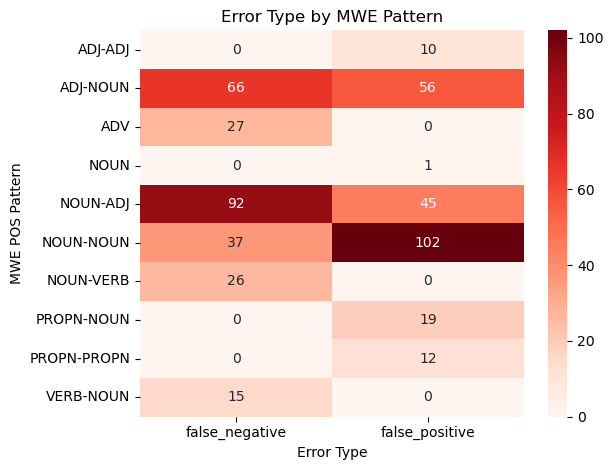

In [20]:
sns.heatmap(
    pd.crosstab(df_errors['mwe_pattern'], df_errors['error_type']),
    cmap="Reds", annot=True, fmt="d"
)
plt.title("Error Type by MWE Pattern")
plt.ylabel("MWE POS Pattern")
plt.xlabel("Error Type")
plt.tight_layout()
plt.savefig("plot_error_mwe_pattern.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("plot_error_mwe_pattern.png", format="png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

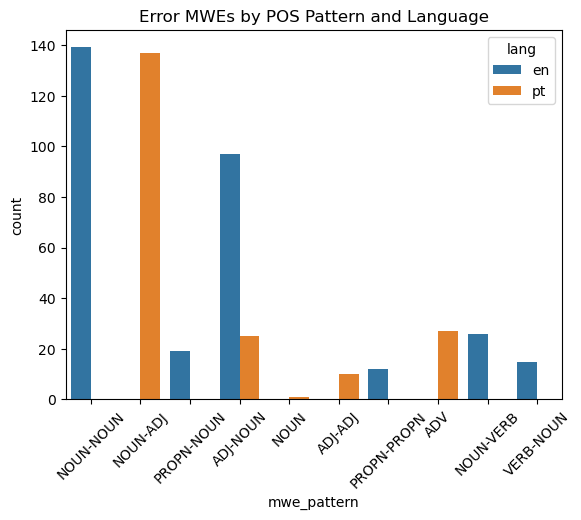

In [21]:
#MWE pattern frequency by lang
sns.countplot(data=df_errors, x='mwe_pattern', hue='lang')
plt.title("Error MWEs by POS Pattern and Language")
plt.xticks(rotation=45)
plt.savefig("plot_error_mwe_pattern_lang.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("plot_error_mwe_pattern_lang.png", format="png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [22]:
#lang count
df_errors['lang'].value_counts()

lang
en    324
pt    246
Name: count, dtype: int64

In [23]:
lang_counts = df_errors['lang'].value_counts().reset_index()
lang_counts.columns = ['Language', 'Error Count']

/var/folders/w6/grz6qnms2h16ppn2mp9bdstr0000gp/T/ipykernel_3172/1368885824.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lang_counts, x='Language', y='Error Count', palette='deep')


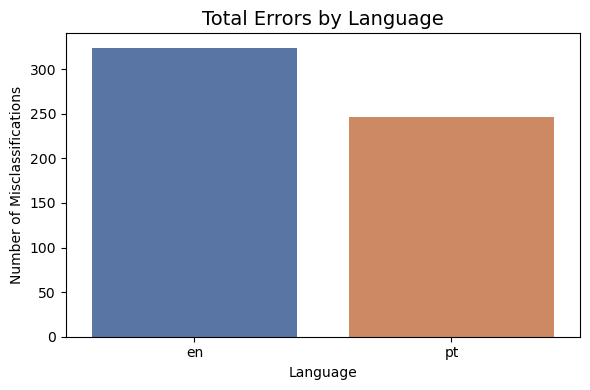

In [24]:
# Plot setup
plt.figure(figsize=(6, 4))
sns.barplot(data=lang_counts, x='Language', y='Error Count', palette='deep')

# Titles and labels
plt.title("Total Errors by Language", fontsize=14)
plt.ylabel("Number of Misclassifications")
plt.xlabel("Language")
plt.tight_layout()

# Save high-res plots
plt.savefig("error_counts_by_language.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.savefig("error_counts_by_language.png", format="png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [25]:
#top misclassified MWE
df_errors['mwe'].value_counts().head(10)

mwe
rice paper           42
dry land             28
alto-falante         27
pillow slip          26
alarme falso         21
desfile militar      21
mental disorder      20
swan song            19
caixeiro viajante    19
fio condutor         18
Name: count, dtype: int64

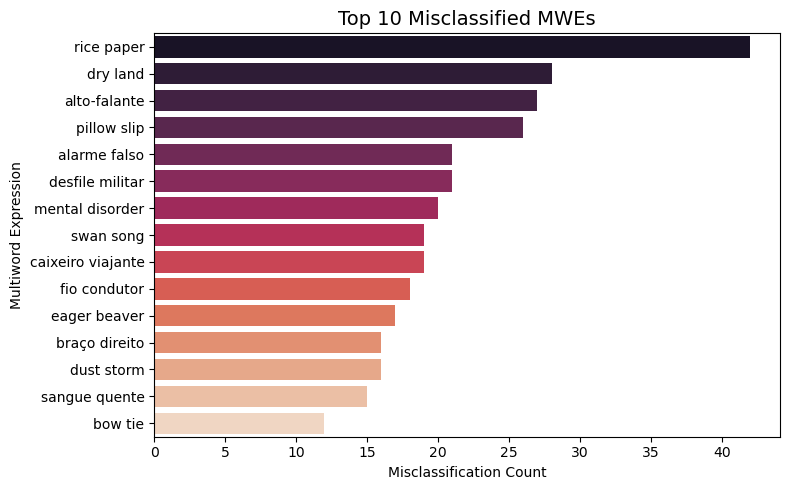

In [26]:
# Get top 10 misclassified MWEs
top_mwes = df_errors['mwe'].value_counts().head(15)

# Plot setup
plt.figure(figsize=(8, 5))
sns.barplot(y=top_mwes.index, x=top_mwes.values, hue=top_mwes.index, palette="rocket", dodge=False, legend=False)


# Titles and labels
plt.title("Top 10 Misclassified MWEs", fontsize=14)
plt.xlabel("Misclassification Count")
plt.ylabel("Multiword Expression")
plt.tight_layout()

# Save high quality plots
plt.savefig("top_misclassified_mwes.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.savefig("top_misclassified_mwes.png", format="png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [28]:
df_errors_sorted = df_errors.sort_values(by='lang', ascending=True)

In [29]:
df_errors_sorted

,id,text,prediction,label,error_type,experiment,lang,mwe,mwe_pattern
200,436,"If you're shopping for a child or children, yo...",1,0,false_positive,MB3,en,life vest,NOUN-NOUN
735,54559,As a board member of the Arizona Association f...,0,1,false_negative,MB4,en,mental disorder,ADJ-NOUN
733,20685,"Sunday at Camp is much like any other day, exc...",0,1,false_negative,MB4,en,pillow slip,NOUN-VERB
731,90196,The captain then takes the traumatized and unt...,0,1,false_negative,MB4,en,dust storm,NOUN-NOUN
727,82073,I wanted to hire him even though I knew I woul...,0,1,false_negative,MB4,en,bow tie,VERB-NOUN
...,...,...,...,...,...,...,...,...,...
306,55035,Com o aumento da demanda por navios que transp...,0,1,false_negative,MB3,pt,papel higiênico,NOUN-ADJ
305,38780,O investimento federal nos dois empreendimento...,0,1,false_negative,MB3,pt,None,None
997,15320,O comandante comentou sobre alguns valores do ...,1,0,false_positive,MB5,pt,None,None
781,77114,A distancia entre as localidades nas quais se ...,0,1,false_negative,MB4,pt,caixeiro viajante,NOUN-ADJ


In [30]:
df_MB3 = df_errors_sorted[df_errors_sorted['experiment'] == 'MB3']
df_MB4 = df_errors_sorted[df_errors_sorted['experiment'] == 'MB4']
df_MB5 = df_errors_sorted[df_errors_sorted['experiment'] == 'MB5']

## Save DFs

In [31]:
# Export experiment clustered
df_MB3.to_csv("MB3.csv", index=False)
df_MB4.to_csv("MB4.csv", index=False)
df_MB5.to_csv("MB5.csv", index=False)

# Export misclassified samples (errors)
df_errors.to_csv("mwe_errors_annotated.csv", index=False)
# Export correctly classified samples
df_correct.to_csv("mwe_correct_annotated.csv", index=False)
df_all_mwe.to_csv("mwe_all_annotated.csv", index=False)